In [2]:
%cp -r ../resources .

In [3]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from Astrid.data_processing import get_weights
from Astrid.config import MC_FILENAMES, PARAMS, PARAMETER_NAMES
from Astrid.effective_area import bin_edges_to_centers, bin_centers_to_edges
import data_loader
import weighter
import binning
import fc
import gc

In [4]:
energy_bins = np.logspace(4, 7, 3*20+1)
energy_bins_low_resolution = np.logspace(4, 7, 20+1)
bin_centers = bin_edges_to_centers(energy_bins_low_resolution)

livetime_75 = 227708167.68      # The exact amount of time that HESE was running for the 7.5 year dataset
livetime12 = 12 * 365 * 24 * 3600
params_dict = dict(zip(PARAMETER_NAMES, PARAMS))
print(params_dict)

{'cr_delta_gamma': np.float64(-0.05309302), 'nunubar_ratio': np.float64(0.99815326), 'anisotropy_scale': np.float64(1.000683), 'astro_gamma': np.float64(2.87375956), 'astro_norm': np.float64(6.36488608), 'conv_norm': np.float64(1.00621679), 'epsilon_dom': np.float64(0.95192328), 'epsilon_head_on': np.float64(-0.0548763), 'muon_norm': np.float64(1.18706341), 'kpi_ratio': np.float64(1.00013744), 'prompt_norm': np.float64(0.0)}


In [5]:
mc = data_loader.load_mc(MC_FILENAMES, emin=energy_bins[0], emax=energy_bins[-1])
data = data_loader.load_data("/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/resources/data/HESE_data.json", emin=energy_bins[0], emax=energy_bins[-1])

In [6]:
data12 = data_loader.load_data("/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/resources/data/HESE12_data.json", emin=energy_bins[0], emax=energy_bins[-1])

In [ ]:
weight_maker = weighter.Weighter(mc)


In [ ]:
mc_cascade = mc[mc['recoMorphology'] == 0]
weight_maker_cascade = weighter.Weighter(mc_cascade)
gc.collect()

mc_track = mc[mc['recoMorphology'] == 1]
weight_maker_track = weighter.Weighter(mc_track)
gc.collect()

mc_dcascade = mc[mc['recoMorphology'] == 2]
weight_maker_dcascade = weighter.Weighter(mc_dcascade)
gc.collect()


Total cascade events: 113.12608582776713
Total track events: 57.48462910320671
Total dcascade events: 4.906829064826898


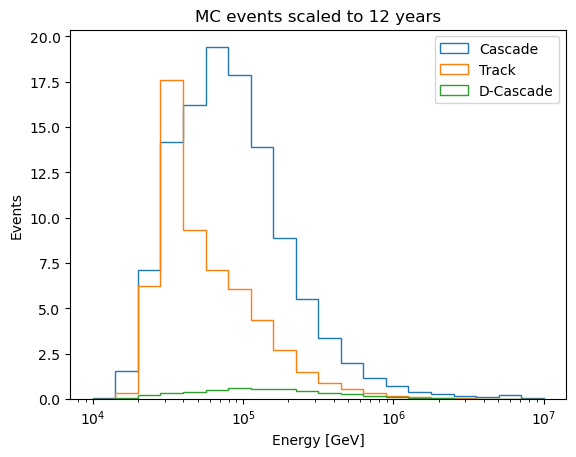

In [ ]:
# Get weights for cascade, track, and dcascade. Signal + Background.
p_copy = params_dict.copy()


cascade_weights = weight_maker_cascade.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
cascade_events, _ = np.histogram(mc_cascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=cascade_weights)
print('Total cascade events:', np.sum(cascade_weights))
gc.collect()


track_weights = weight_maker_track.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
track_events, _ = np.histogram(mc_track['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=track_weights)
print('Total track events:', np.sum(track_weights))


dcascade_weights = weight_maker_dcascade.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
dcascade_events, _ = np.histogram(mc_dcascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=dcascade_weights)
print('Total dcascade events:', np.sum(dcascade_weights))

plt.hist(mc_cascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=cascade_weights, histtype='step', label='Cascade')
plt.hist(mc_track['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=track_weights, histtype='step', label='Track')
plt.hist(mc_dcascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=dcascade_weights, histtype='step', label='D-Cascade')
plt.xscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Events')
plt.title('MC events scaled to 12 years')
plt.legend()
plt.show()


Total cascade events: 113.12608582776713
Total track events: 57.48462910320671
Total dcascade events: 4.906829064826898


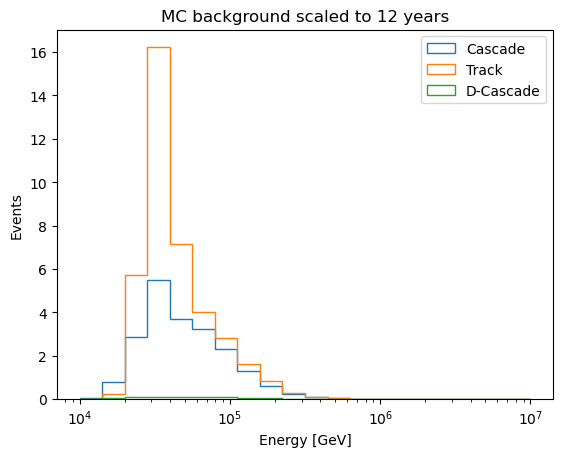

In [ ]:
# Get weights for cascade, track, and dcascade. Background only.
p_copy = params_dict.copy()
p_copy["astro_norm"] = 0.0

cascade_weights_background = weight_maker_cascade.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
cascade_events_background, _ = np.histogram(mc_cascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=cascade_weights_background)
print('Total cascade events:', np.sum(cascade_events_background))
gc.collect()

track_weights_background = weight_maker_track.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
track_events_background, _ = np.histogram(mc_track['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=track_weights_background)
print('Total track events:', np.sum(track_events_background))
gc.collect()

dcascade_weights_background = weight_maker_dcascade.get_weights(livetime12, p_copy.keys(), p_copy.values())[0]
dcascade_events_background, _ = np.histogram(mc_dcascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=dcascade_weights_background)
print('Total dcascade events:', np.sum(dcascade_events_background))
gc.collect()

plt.hist(mc_cascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=cascade_weights_background, histtype='step', label='Cascade')
plt.hist(mc_track['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=track_weights_background, histtype='step', label='Track')
plt.hist(mc_dcascade['recoDepositedEnergy'], bins=energy_bins_low_resolution, weights=dcascade_weights_background, histtype='step', label='D-Cascade')
plt.xscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Events')
plt.title('MC background scaled to 12 years')
plt.legend()
plt.show()

In [11]:
print('totale cascade background events:', np.sum(cascade_events_background))
print('totale track background events:', np.sum(track_events_background))
print('totale dcascade background events:', np.sum(dcascade_events_background))

totale cascade background events: 20.82110159900834
totale track background events: 39.137880481360575
totale dcascade background events: 0.6471131519465909


164
[]
[ 0  0 10 17 18 11 19 17  6  3  3  1  1  2  0  1  0  0  0  0]
[ 0  1  8  8  7 12  8  6  2  1  1  0  0  0  0  0  0  1  0  0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
              events
1.188502e+04       0
1.678804e+04       0
2.371374e+04      10
3.349654e+04      17
4.731513e+04      18
6.683439e+04      11
9.440609e+04      19
1.333521e+05      17
1.883649e+05       6
2.660725e+05       3
3.758374e+05       3
5.308844e+05       1
7.498942e+05       1
1.059254e+06       2
1.496236e+06       0
2.113489e+06       1
2.985383e+06       0
4.216965e+06       0
5.956621e+06       0
8.413951e+06       0


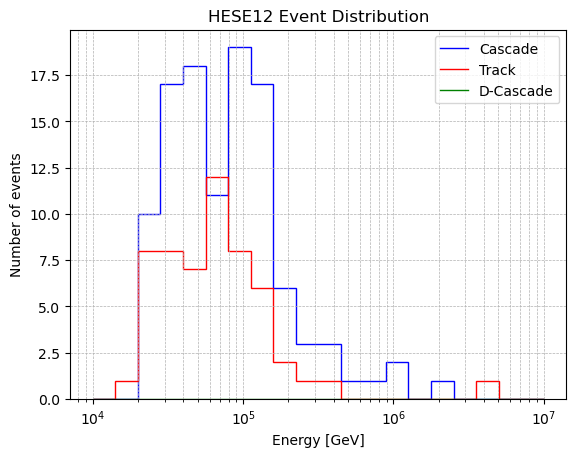

In [ ]:
cascade_energies12 = data12['recoDepositedEnergy'][data12['recoMorphology'] == 0]
track_energies12 = data12['recoDepositedEnergy'][data12['recoMorphology'] == 1]
dcascade_energies12 = data12['recoDepositedEnergy'][data12['recoMorphology'] == 2]

cascade_events_12, bin_edges = np.histogram(cascade_energies12, bins=energy_bins_low_resolution)
track_events_12, bin_edges = np.histogram(track_energies12, bins=energy_bins_low_resolution)
dcascade_events_12, bin_edges = np.histogram(dcascade_energies12, bins=energy_bins_low_resolution)


cascade_df = pd.DataFrame(cascade_events_12, index=bin_centers, columns=['events'])
track_df = pd.DataFrame(track_events_12, index=bin_centers, columns=['events'])
dcascade_df = pd.DataFrame(dcascade_events_12, index=bin_centers, columns=['events'])

plt.stairs(cascade_events_12, bin_edges, fill=False, color='blue', label='Cascade')
plt.stairs(track_events_12, bin_edges, fill=False, color='red', label='Track')
plt.stairs(dcascade_events_12, bin_edges, fill=False, color='green', label='D-Cascade')
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('HESE12 Event Distribution')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

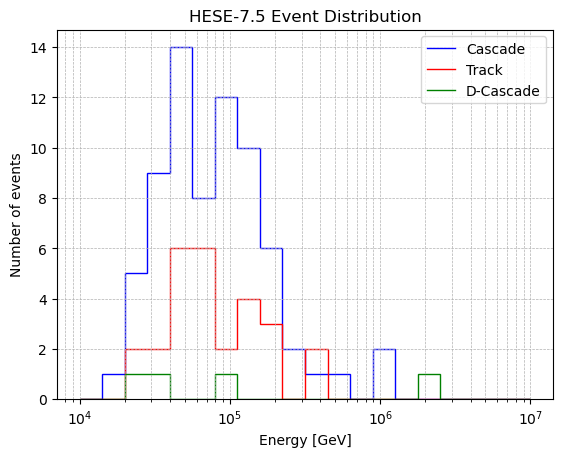

In [15]:


cascade_energies75 = data['recoDepositedEnergy'][data['recoMorphology'] == 0]
track_energies75 = data['recoDepositedEnergy'][data['recoMorphology'] == 1]
dcascade_energies75 = data['recoDepositedEnergy'][data['recoMorphology'] == 2]

cascade_events75, _ = np.histogram(cascade_energies75, bins=energy_bins_low_resolution)
track_events75, _ = np.histogram(track_energies75, bins=energy_bins_low_resolution)
dcascade_events75, _ = np.histogram(dcascade_energies75, bins=energy_bins_low_resolution)

cascade75_df = pd.DataFrame(cascade_events75, index=bin_centers, columns=['events'])
track75_df = pd.DataFrame(track_events75, index=bin_centers, columns=['events'])
dcascade75_df = pd.DataFrame(dcascade_events75, index=bin_centers, columns=['events'])


plt.stairs(cascade_events75, energy_bins_low_resolution, fill=False, color='blue', label='Cascade')
plt.stairs(track_events75, energy_bins_low_resolution, fill=False, color='red', label='Track')
plt.stairs(dcascade_events75, energy_bins_low_resolution, fill=False, color='green', label='D-Cascade')
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('HESE-7.5 Event Distribution')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

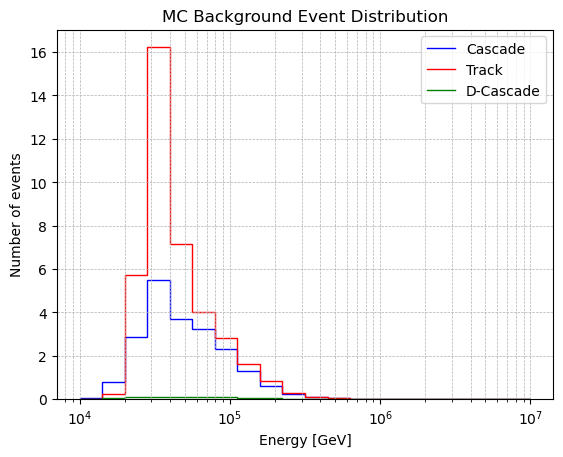

Get the HESE12 events and bin them into the low resolution bins. 

Do the same for the background but using the MC events/weights.

Compute the energy centers, the distance from the centers to the upper and lower edges respectively (used for plotting), and also the full width of the bin (used for computing the flux and its errors).

In [ ]:
energies_12 = data12['recoDepositedEnergy']

# Bin centers
events_data_12, bin_edges = np.histogram(energies_12, bins=energy_bins_low_resolution)
bin_centers = bin_edges_to_centers(bin_edges)
print(events_data_12)

hese12_df = pd.DataFrame(events_data_12, index=bin_centers, columns=['events'])

# Calculate error bars as distance from center to edges
xerr = [bin_centers - bin_edges[:-1], bin_edges[1:] - bin_centers]

# Compute the full width of the bin
delta_E = np.diff(bin_edges)


energies_background = mc['recoDepositedEnergy']

events_background, bin_edges = np.histogram(energies_background, bins=energy_bins_low_resolution, weights=background_weights)
print(events_background)

[ 0  1 18 25 25 23 27 23  8  4  4  1  1  2  0  1  0  1  0  0]
[4.17028126e-02 1.11190834e+00 8.67407214e+00 2.18430228e+01
 1.09558017e+01 7.34753717e+00 5.26544292e+00 2.97738346e+00
 1.45906303e+00 5.60310212e-01 2.24039824e-01 9.53691867e-02
 3.29391401e-02 1.20800217e-02 3.50823296e-03 1.25782970e-03
 4.28982870e-04 1.49167011e-04 6.50438962e-05 1.32054623e-05]


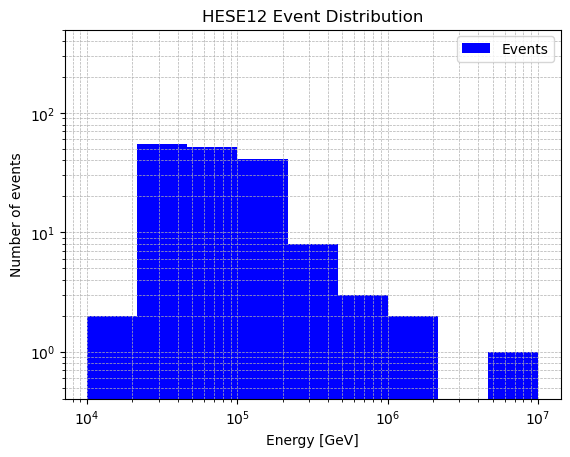

In [61]:
plt.stairs(events_data_12, bin_edges, fill=True, color='blue', label='Events')
plt.xscale('log')
plt.yscale('log')
plt.ylim(4*1e-1, 5*1e2)
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('HESE12 Event Distribution')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

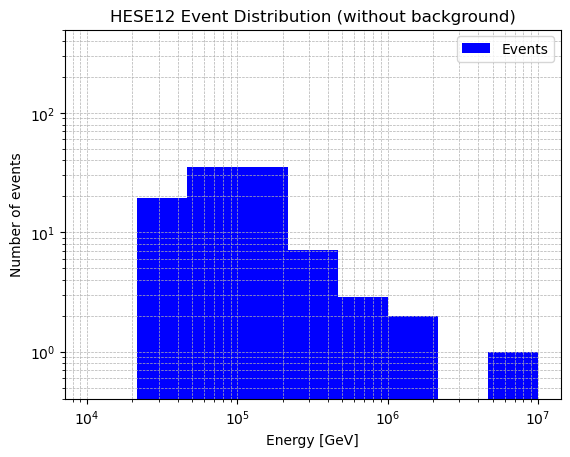

In [38]:
plt.stairs(events_data_12-events_background, bin_edges, fill=True, color='blue', label='Events')
plt.xscale('log')
plt.yscale('log')
plt.ylim(4*1e-1, 5*1e2)
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('HESE12 Event Distribution (without background)')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

Plot the event spectrum of the HESE12 data.

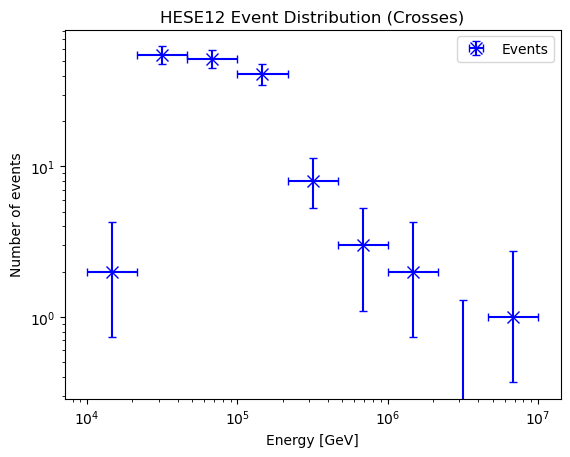

In [39]:

# The error bars are obtained using fc.py, a function writen by Austin Schneider
# and found at https://github.com/austinschneider/feldman_cousins/blob/master/fc.py
one_sigma_proportion = scipy.special.erf(1.0 / np.sqrt(2.0))
yerr = np.array(
    [
        (lambda x: [k - x[0], x[1] - k])(
            fc.poisson_interval(k, alpha=one_sigma_proportion)
        )
        for k in events_data_12
    ]
).T

# Poisson error bars (sqrt(N))
#errors_data_12 = np.sqrt(events_data_12)


plt.errorbar(
    bin_centers, events_data_12, yerr=yerr, xerr=xerr, fmt='x', color='blue', label='Events',
    capsize=3, markersize=8, linestyle='none'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('HESE12 Event Distribution (Crosses)')
plt.legend()
plt.show()

Do the same for the scaled MC background.

[2.00759692e+00 3.55201799e+01 1.64462036e+01 5.60388474e+00
 8.97290446e-01 1.19845695e-01 1.00434223e-02 9.52705255e-04
 9.78559825e-05]


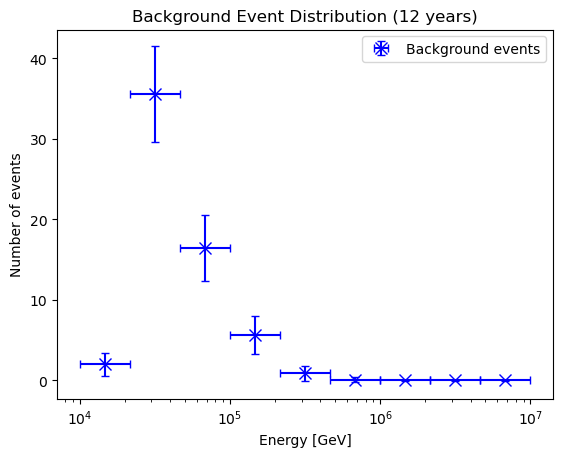

In [81]:
errors_background = np.sqrt(events_background)
print(events_background)

plt.errorbar(
    bin_centers, events_background, yerr=errors_background, xerr=xerr, fmt='x', color='blue', label='Background events',
    capsize=3, markersize=8, linestyle='none'
)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('Background Event Distribution (12 years)')
plt.legend()
plt.show()

Get the effective area and bin it.

Take the total area for all flavors as the HESE12 dataset does not contain flavor information.

Possible idea: As HESE12 contain information about shower/track, could be an idea to get the effective area in terms of NC/CC/GR?

In [101]:
eff_df = pd.read_csv('effective_area_4_to_7.csv', index_col=0)
eff_df['total'] = eff_df['nu_e'] + eff_df['nu_mu'] + eff_df['nu_tau']
#energy_edges_old = np.logspace(4, 7, 3*20+1)
energy_centers_old = eff_df.index.values

eff_tot_binned, _ = np.histogram(energy_centers_old, weights=eff_df['total'], bins=energy_bins_low_resolution)
print(eff_tot_binned)




[9.15856936e-02 3.38818375e+00 3.66017140e+01 1.37031892e+02
 2.37691414e+02 4.55399254e+02 7.14555291e+02 8.85414710e+02
 3.29760984e+03]


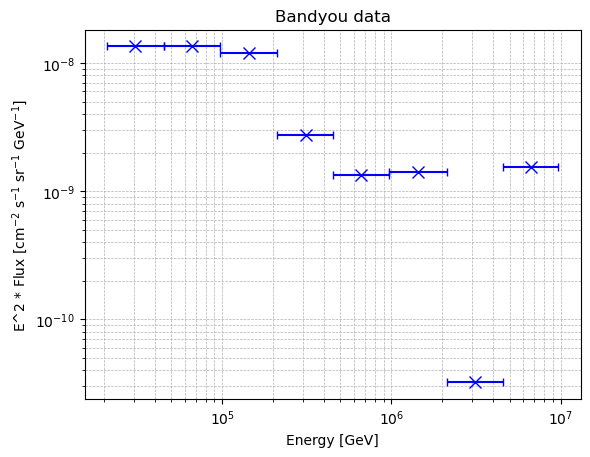

In [88]:
df = pd.read_csv('bandyo_data.csv', header=None)
df.columns = ['energy', 'E^2 * flux']

centers_bandyo = df['energy'].values
edges_bandyo = bin_centers_to_edges(centers_bandyo)
# Calculate error bars as distance from center to edges
xerr_bandyo = [centers_bandyo - edges_bandyo[:-1], edges_bandyo[1:] - centers_bandyo]

# Compute the full width of the bin
#delta_E = np.diff(bin_edges)



plt.errorbar(df['energy'], df['E^2 * flux'], xerr=xerr_bandyo, fmt='x', color='blue', label='Events', capsize=3, markersize=8, linestyle='none')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('E^2 * Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$]')
plt.title('Bandyou data')
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()

Now compute the flux phi in units [GeV^-1 cm^-1 s^-1 sr^-1].

In [102]:
print(delta_E)

[  11544.34690032   24871.54143581   53584.11166387  115443.46900319
  248715.41435809  535841.11663872 1154434.69003188 2487154.14358089
 5358411.16638723]


/tmp/ipykernel_999/3750817697.py:4: RuntimeWarning: invalid value encountered in divide
  flux_err = flux / np.sqrt(events_data_12)


[4.32814636e-05 1.37118267e-04 5.11448020e-05 4.59051894e-05
 2.20077718e-05 1.83581334e-05 3.32425046e-05 0.00000000e+00
 6.54184591e-05]


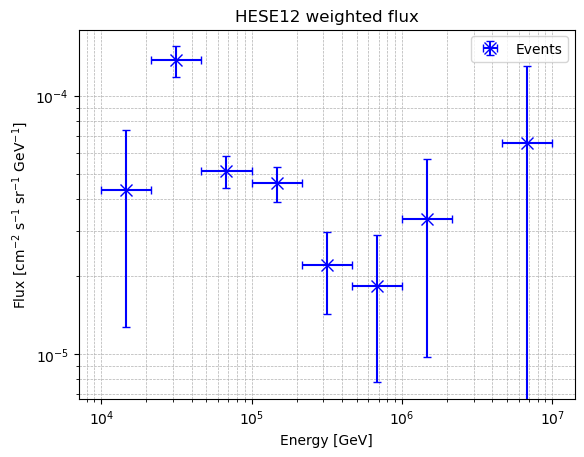

In [108]:

# Factor of 1e4 to convert from m^2 to cm^2
flux = events_data_12 / (delta_E * eff_tot_binned * livetime12 * 4*np.pi * 1e4)

flux_err = flux / np.sqrt(events_data_12)

si = 2.8888
yerr = bin_centers**si * flux_err
print(bin_centers**si * flux)

plt.errorbar(bin_centers, bin_centers**si * flux, xerr=xerr, yerr=yerr, fmt='x', color='blue', label='Events', capsize=3, markersize=8, linestyle='none')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$]')
plt.title('HESE12 weighted flux')
plt.legend()
plt.grid(axis='both', which='both', linestyle='--', linewidth=0.5)
plt.show()






Remove the scaled MC background from the HESE12 data.

/tmp/ipykernel_999/1885945325.py:3: RuntimeWarning: invalid value encountered in sqrt
  errors_data_no_background = np.sqrt(data_no_background)


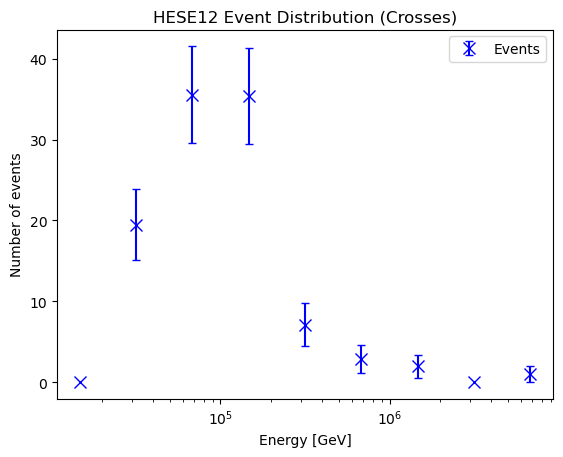

In [46]:



data_no_background = events_data_12 - events_background

errors_data_no_background = np.sqrt(data_no_background)

plt.errorbar(
    bin_centers, data_no_background, yerr=errors_data_no_background, fmt='x', color='blue', label='Events',
    capsize=3, markersize=8, linestyle='none'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('HESE12 Event Distribution (without background)')
plt.legend()
plt.show()


/tmp/ipykernel_999/4205588815.py:4: RuntimeWarning: invalid value encountered in sqrt
  flux_err = flux_no_background / np.sqrt(data_no_background)


[-3.25518887e-11  4.86090987e-09  1.76936517e-09  1.01367840e-09
  2.52644671e-10  1.15201028e-10  1.09288385e-10 -9.09727680e-14
  5.52320475e-11]


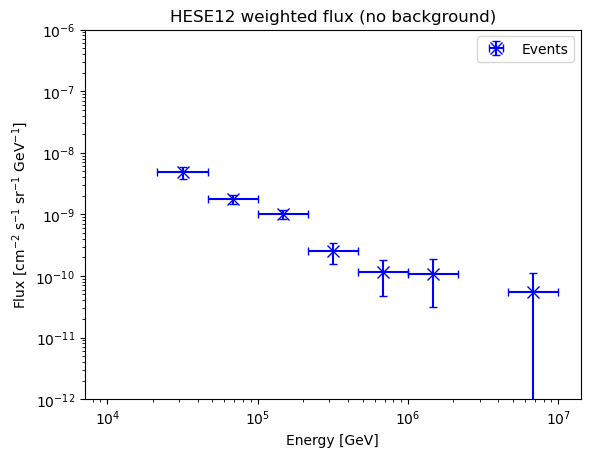

In [51]:

# Factor of 1e4 to convert from m^2 to cm^2
flux_no_background = data_no_background / (delta_E * eff_tot_binned * livetime12 * 4*np.pi * 1e4)

flux_err = flux_no_background / np.sqrt(data_no_background)

si = 2.0
err_tot = bin_centers**si * flux_err
print(bin_centers**si * flux_no_background)

plt.errorbar(bin_centers, bin_centers**si * flux_no_background, xerr=xerr, yerr=err_tot, fmt='x', color='blue', label='Events', capsize=3, markersize=8, linestyle='none')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-12, 1e-6)
plt.xlabel('Energy [GeV]')
plt.ylabel('Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$]')
plt.title('HESE12 weighted flux (no background)')
plt.legend()
plt.show()

In [48]:
print(flux_no_background)

[-1.51092483e-19  4.86090987e-18  3.81198169e-19  4.70507837e-20
  2.52644671e-21  2.48193092e-22  5.07271747e-23 -9.09727680e-27
  1.18993839e-24]
